In [9]:
import numpy as np
import pandas as pd

In [2]:
from sys import getsizeof
np.random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Criando listas de dados
letras = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
numeros = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
booleanos = [True, False, np.nan, True, False, np.nan, True, False, np.nan, True]
len(letras) == len(numeros) == len(booleanos)

True

In [4]:
dicio = {
    'letras': letras,
    'numeros': numeros,
    'booleanos': booleanos
}
dicio

{'letras': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
 'numeros': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'booleanos': [True, False, nan, True, False, nan, True, False, nan, True]}

In [6]:
df = pd.DataFrame(dicio)
df

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [14]:
#Instanciando uma DataFrame a partir de um dicionário de listas
valores = {
    "valores": np.random.randint(1, 100, size=7),
    "letras": [i for i in "ABEFGIJ"]
}

df2 = pd.DataFrame(valores)
df2

,valores,letras
0,87,A
1,75,B
2,75,E
3,88,F
4,24,G
5,3,I
6,22,J


In [15]:
#Juntando os DataFrame utilizando a coluna 'letras' como chave
df.merge(df2, on="letras")

,letras,numeros,booleanos,valores
0,A,1,True,87
1,B,2,False,75
2,E,5,False,75
3,F,6,NaN,88
4,G,7,True,24
5,I,9,NaN,3
6,J,10,True,22


In [16]:
#Utilizando o parâmetro 'how' para definir o tipo de junção
df.merge(df2, on="letras", how="left")

,letras,numeros,booleanos,valores
0,A,1,True,87.0
1,B,2,False,75.0
2,C,3,NaN,NaN
3,D,4,True,NaN
4,E,5,False,75.0
5,F,6,NaN,88.0
6,G,7,True,24.0
7,H,8,False,NaN
8,I,9,NaN,3.0
9,J,10,True,22.0


In [17]:
#Conectando os DF utilizando o método concat
pd.concat([df, df2], axis=0)

,letras,numeros,booleanos,valores
0,A,1.0,True,NaN
1,B,2.0,False,NaN
2,C,3.0,NaN,NaN
3,D,4.0,True,NaN
4,E,5.0,False,NaN
5,F,6.0,NaN,NaN
6,G,7.0,True,NaN
7,H,8.0,False,NaN
8,I,9.0,NaN,NaN
9,J,10.0,True,NaN


In [ ]:
#Conectando os DF utilizando o método concat (COM OUTRO EIXO)
pd.concat([df, df2], axis=1)

,letras,numeros,booleanos,valores,letras
0,A,1,True,87.0,A
1,B,2,False,75.0,B
2,C,3,NaN,75.0,E
3,D,4,True,88.0,F
4,E,5,False,24.0,G
5,F,6,NaN,3.0,I
6,G,7,True,22.0,J
7,H,8,False,NaN,NaN
8,I,9,NaN,NaN,NaN
9,J,10,True,NaN,NaN


In [ ]:
df

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [21]:
#recuperar as primeiras é head, as ultimas é tail (coloca o num só se quiser especifico)
df.head()

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False


In [25]:
#info das DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   letras     10 non-null     object
 1   numeros    10 non-null     int64 
 2   booleanos  7 non-null      object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [26]:
#describe te dá medidas
df.describe()

,numeros
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


In [29]:
#medidas resumo das colunas NÃO numericas do DF
df.select_dtypes(exclude='number').describe()

,letras,booleanos
count,10,7
unique,10,2
top,A,True
freq,1,4


In [30]:
#Indexando valores da segunda linha
df.loc[1]

letras           B
numeros          2
booleanos    False
Name: 1, dtype: object

In [ ]:
#Indexando valores da ultima linha (i é de inteiro, só com NÚMEROS)
df.iloc[-1]

letras          J
numeros        10
booleanos    True
Name: 9, dtype: object

In [36]:
df.loc[:,['numeros']]

,numeros
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
#conta as ocorrencias de cada coisa no bool
df['booleanos'].value_counts()

booleanos
True     4
False    3
Name: count, dtype: int64

In [ ]:
#construtor = codigo para construir algo (vem do pandas), posso usar para somar também!
df.groupby('booleanos')

In [39]:
df.groupby('booleanos').sum()

,letras,numeros
booleanos,,
False,BEH,15
True,ADGJ,22


In [40]:
df[['numeros','booleanos']].groupby('booleanos').sum()

,numeros
booleanos,
False,15
True,22


<Axes: xlabel='numeros', ylabel='booleanos'>

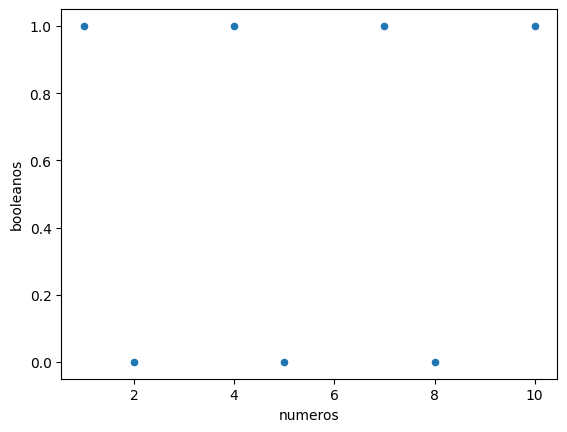

In [ ]:
#para construir gráfico!
df.plot(x= 'numeros', y='booleanos', kind='scatter')

<Axes: ylabel='numeros'>

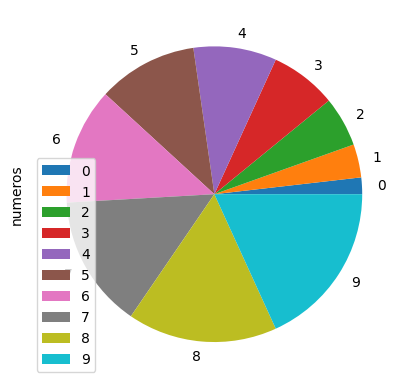

In [43]:
#para construir gráfico!
df.plot(y= 'numeros', kind='pie')

In [44]:
os.listdir()

['.git',
 '.venv',
 'arq.ipynb',
 'exercício_aula02_Zem.ipynb',
 'exercício_aula04_Zem.ipynb',
 'exercício_aula05_Zem.ipynb',
 'exercício_aula06_Zem.ipynb',
 'img',
 'notenovo_Gui.ipynb',
 'testes_práticas.ipynb']

In [46]:
#####operadores aritméticos
a = 2
b = 3
c = 4
print (f"{a} == {b}: {a == b}")
print (f"{a} != {b}: {a!=b}")


2 == 3: False
2 != 3: True


In [ ]:
#ENTRE TUPLAS E LISTAS SÓ ==, !=, mesma coisa em dicionários/dicionários (pois é index manual)
#entre tupla/tupla e lista/lista consegue todas as operações.
#se fizer obj_tupla_int = np.array([1, 0, 1, 0]) (com o outro tbm), ele compara todos os valores dentro dos dois!

obj_tupla_int = (1, 0, 1, 0)
obj_tupla_bool = (True, False, True, False)

print(f"(obj_tupla_int) == {obj_tupla_bool}: {obj_tupla_int == obj_tupla_bool}")
print(f"(obj_tupla_int) != {obj_tupla_bool}: {obj_tupla_int != obj_tupla_bool}")


(obj_tupla_int) == (True, False, True, False): True
(obj_tupla_int) != (True, False, True, False): False
